# Семинар 4. Single-cell RNA-seq: PBMC 3k в Scanpy

## Окружение, данные и служебные функции


In [1]:
from pathlib import Path
import hashlib
import json
import tarfile
import urllib.request
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy import sparse

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="zero-centering a sparse array/matrix densifies it")
sc.settings.verbosity = 1
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160, "axes.titlesize": 10})

ROOT = Path(".")
WORK = ROOT / "work"
DATA = WORK / "data"
FIG = ROOT / "figures"
TABLES = ROOT / "tables"
for p in (WORK, DATA, FIG, TABLES):
    p.mkdir(parents=True, exist_ok=True)

URL = "https://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz"
ARCHIVE = DATA / "pbmc3k.tar.gz"
MTX_DIR = DATA / "filtered_gene_bc_matrices" / "hg19"

if not MTX_DIR.exists():
    if not ARCHIVE.exists():
        urllib.request.urlretrieve(URL, ARCHIVE)
    if not tarfile.is_tarfile(ARCHIVE):
        raise RuntimeError("Архив PBMC3k повреждён или имеет неверный формат")
    with tarfile.open(ARCHIVE, "r:gz") as tf:
        tf.extractall(DATA, filter="data")

required = [MTX_DIR / "matrix.mtx", MTX_DIR / "genes.tsv", MTX_DIR / "barcodes.tsv"]
if not all(p.exists() and p.stat().st_size > 0 for p in required):
    raise RuntimeError("После распаковки отсутствуют обязательные файлы PBMC3k")

sha256 = hashlib.sha256(ARCHIVE.read_bytes()).hexdigest() if ARCHIVE.exists() else None
print("scanpy", sc.__version__)
print("data", MTX_DIR)
print("archive sha256", sha256)

def dense1(x):
    return np.asarray(x.toarray() if sparse.issparse(x) else x).ravel()

def gene_values(adata, gene):
    if gene not in adata.var_names:
        return np.full(adata.n_obs, np.nan)
    return dense1(adata[:, gene].X)

def mean_var(X):
    if sparse.issparse(X):
        mean = np.asarray(X.mean(axis=0)).ravel()
        mean2 = np.asarray(X.multiply(X).mean(axis=0)).ravel()
    else:
        mean = np.asarray(X.mean(axis=0)).ravel()
        mean2 = np.asarray((X * X).mean(axis=0)).ravel()
    return mean, np.maximum(mean2 - mean**2, 0)

def run_pca(adata, mask=None, n_comps=30):
    x = adata.copy()
    sc.tl.pca(x, n_comps=min(n_comps, x.n_obs - 1), mask_var=mask,
              svd_solver="arpack", random_state=0)
    return x

def save_show(name):
    path = FIG / name
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print("saved", path)

def scatter_embedding(ax, emb, color, title, cmap="viridis", categorical=False):
    if categorical:
        cats = pd.Categorical(color)
        palette = sns.color_palette("Set2", len(cats.categories))
        for i, label in enumerate(cats.categories):
            m = cats.codes == i
            ax.scatter(emb[m, 0], emb[m, 1], s=7, alpha=.75, color=palette[i], label=str(label), rasterized=True)
        ax.legend(frameon=False, fontsize=7, markerscale=1.8)
    else:
        pts = ax.scatter(emb[:, 0], emb[:, 1], c=color, s=6, alpha=.8, cmap=cmap, rasterized=True)
        plt.colorbar(pts, ax=ax, fraction=.046, pad=.02)
    ax.set(title=title, xlabel="PC1", ylabel="PC2")

scanpy 1.11.5
data work/data/filtered_gene_bc_matrices/hg19
archive sha256 847d6ebd9a1ec9a768f2be7e40ca42cbfe75ebeb6d76a4c24167041699dc28b5


## Базовый pipeline: AnnData и QC

`AnnData.X` хранит основную матрицу клетки × гены; `obs` и `var` — аннотации клеток и генов; `layers` — дополнительные матрицы той же формы; `obsm`/`varm` — многомерные представления клеток/генов; `obsp`/`varp` — попарные отношения; `uns` — неструктурированные результаты; `raw` — отдельный снимок `X` и `var`.

Кроме митохондриальных генов `MT-`, проверяем рибосомные `RPL/RPS` и гемоглобиновые `HBA/HBB`. Это эвристики по символам генов, поэтому для другого организма или другой аннотации надёжнее использовать genomic coordinates и gene biotype из согласованного GTF/GFF.

In [2]:
adata_raw = sc.read_10x_mtx(MTX_DIR, var_names="gene_symbols", cache=False)
adata_raw.var_names_make_unique()
adata_raw.var["mt"] = adata_raw.var_names.str.startswith("MT-")
adata_raw.var["ribo"] = adata_raw.var_names.str.startswith(("RPL", "RPS"))
adata_raw.var["hb"] = adata_raw.var_names.str.match(r"^HB[AB](?!P)")
sc.pp.calculate_qc_metrics(adata_raw, qc_vars=["mt", "ribo", "hb"], percent_top=None, log1p=False, inplace=True)

raw_shape = adata_raw.shape
qc_gene_counts = {k: int(adata_raw.var[k].sum()) for k in ["mt", "ribo", "hb"]}
print(adata_raw)
print("matrix type:", type(adata_raw.X), "dtype:", adata_raw.X.dtype)
print("gene names:", adata_raw.var_names[:8].tolist())
print("QC genes:", qc_gene_counts)
adata_raw.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"]].describe().round(2)

AnnData object with n_obs × n_vars = 2700 × 32738
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
matrix type: <class 'scipy.sparse._csc.csc_matrix'> dtype: float32
gene names: ['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8', 'AL627309.1', 'RP11-34P13.14', 'RP11-34P13.9']
QC genes: {'mt': 13, 'ribo': 106, 'hb': 3}


,total_counts,n_genes_by_counts,pct_counts_mt,pct_counts_ribo,pct_counts_hb
count,2700.00,2700.00,2700.00,2700.00,2700.00
mean,2366.90,846.99,2.22,34.95,0.00
std,1094.26,282.10,1.17,10.22,0.03
min,548.00,212.00,0.00,1.06,0.00
25%,1757.75,690.00,1.54,26.33,0.00
50%,2197.00,817.00,2.03,36.77,0.00
75%,2763.00,953.25,2.64,43.35,0.00
max,15844.00,3422.00,22.57,59.44,1.31


### Задание 1. Расширенный QC

Violin и histogram показывают распределения метрик по всем 2700 cell barcodes. На scatter используем `total_counts` по X и `n_genes_by_counts` по Y, а цветом — долю каждой дополнительной группы. Подозрительными считаем крайние сочетания: мало генов/UMI, высокая митохондриальная доля или очень много генов/UMI (возможные doublets). Высокая доля рибосомных или гемоглобиновых транскриптов сама по себе не доказывает плохое качество: она может отражать тип и состояние клетки или ambient RNA.

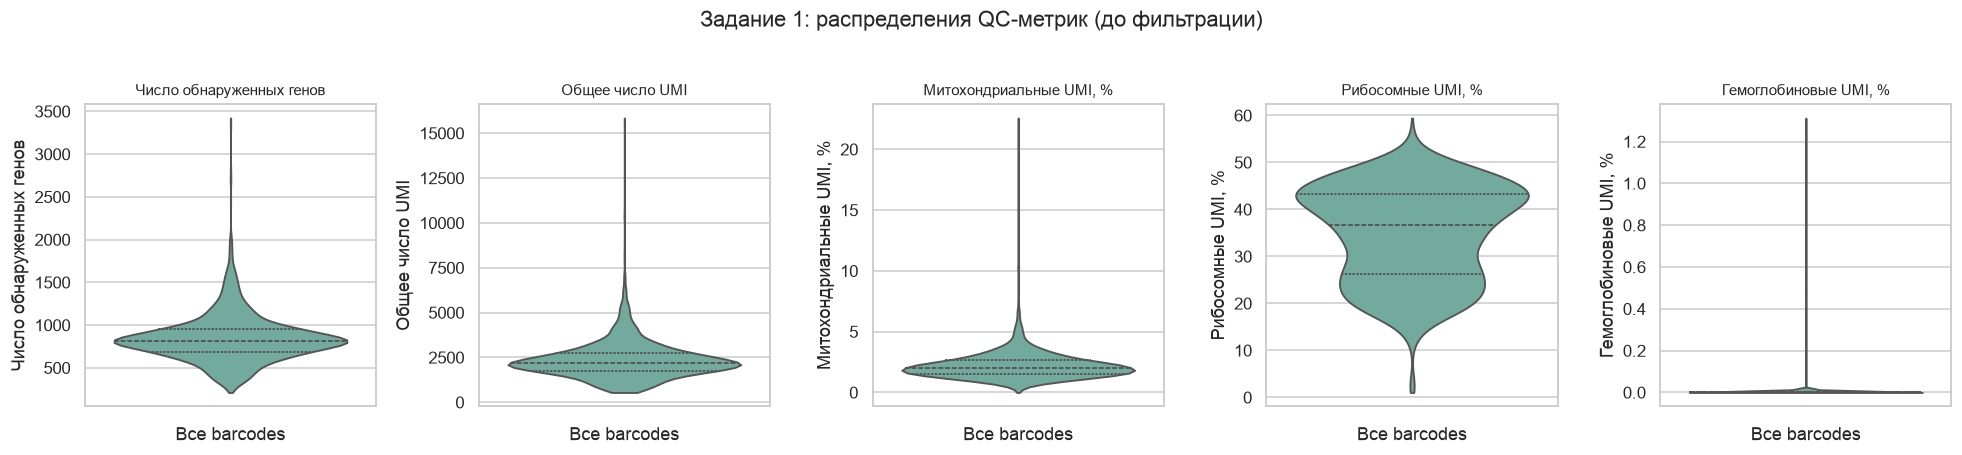

saved figures/01_qc_violin.png


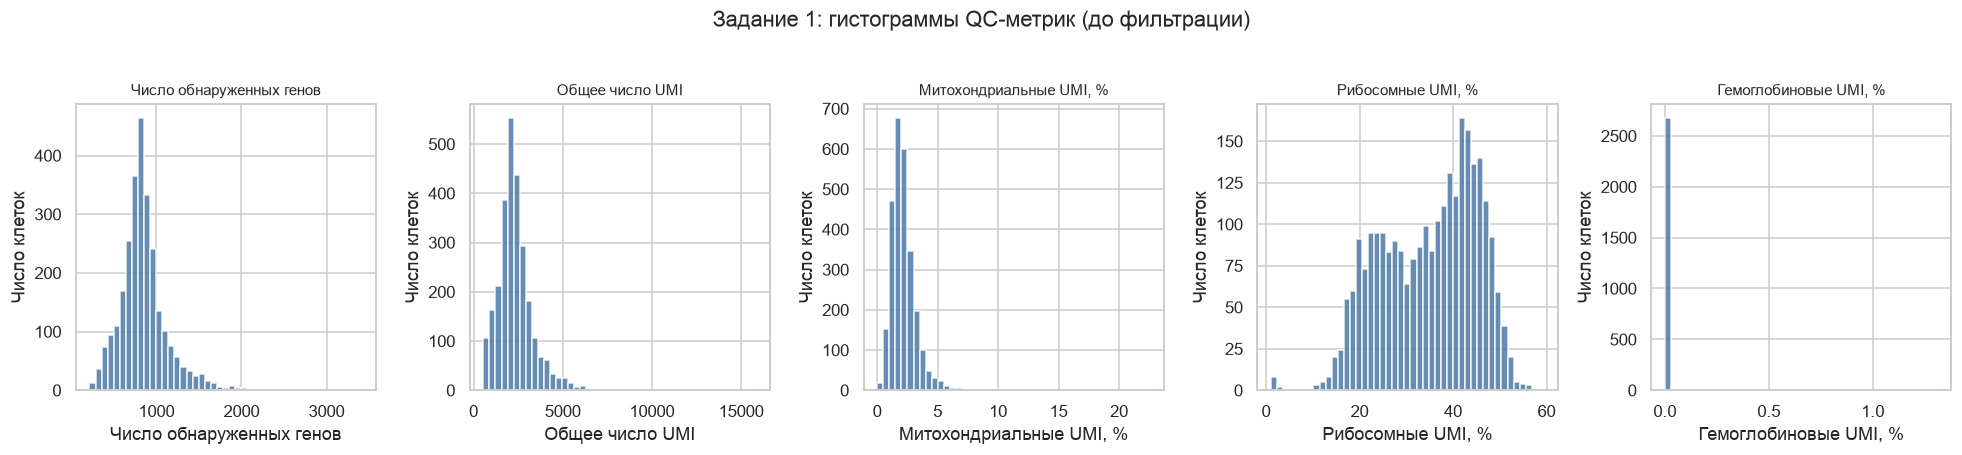

saved figures/02_qc_histograms.png


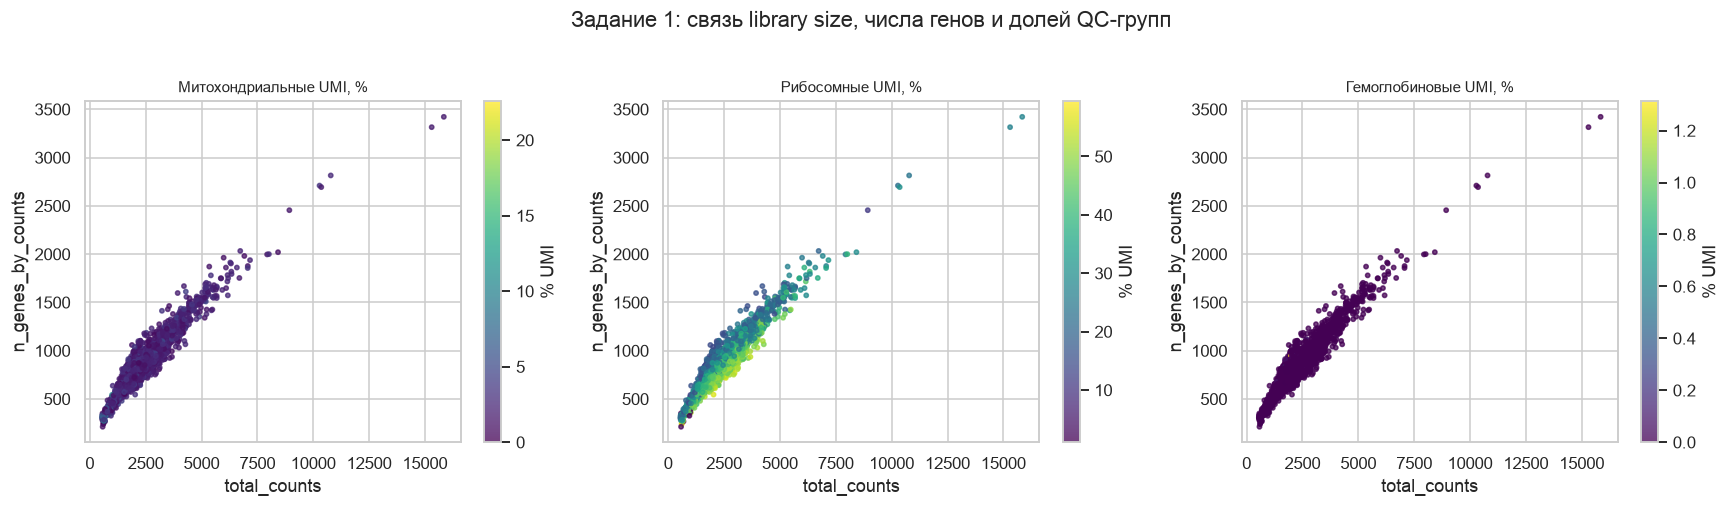

saved figures/03_qc_scatter.png


In [3]:
qc_metrics = ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"]
qc_labels = {
    "n_genes_by_counts": "Число обнаруженных генов",
    "total_counts": "Общее число UMI",
    "pct_counts_mt": "Митохондриальные UMI, %",
    "pct_counts_ribo": "Рибосомные UMI, %",
    "pct_counts_hb": "Гемоглобиновые UMI, %",
}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, m in zip(axes, qc_metrics):
    sns.violinplot(y=adata_raw.obs[m], ax=ax, color="#69b3a2", inner="quartile", cut=0)
    ax.set(xlabel="Все barcodes", ylabel=qc_labels[m], title=qc_labels[m])
fig.suptitle("Задание 1: распределения QC-метрик (до фильтрации)", y=1.03)
plt.tight_layout(); save_show("01_qc_violin.png")

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, m in zip(axes, qc_metrics):
    ax.hist(adata_raw.obs[m], bins=45, color="#4c78a8", alpha=.85)
    ax.set(xlabel=qc_labels[m], ylabel="Число клеток", title=qc_labels[m])
fig.suptitle("Задание 1: гистограммы QC-метрик (до фильтрации)", y=1.03)
plt.tight_layout(); save_show("02_qc_histograms.png")

color_metrics = ["pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, m in zip(axes, color_metrics):
    pts = ax.scatter(adata_raw.obs.total_counts, adata_raw.obs.n_genes_by_counts,
                     c=adata_raw.obs[m], s=8, alpha=.75, cmap="viridis", rasterized=True)
    ax.set(xlabel="total_counts", ylabel="n_genes_by_counts", title=qc_labels[m])
    plt.colorbar(pts, ax=ax, label="% UMI")
fig.suptitle("Задание 1: связь library size, числа генов и долей QC-групп", y=1.02)
plt.tight_layout(); save_show("03_qc_scatter.png")

In [4]:
# Фильтрация строго по параметрам исходного notebook.
adata_f = adata_raw.copy()
n0, g0 = adata_f.shape
sc.pp.filter_cells(adata_f, min_genes=200)
n_after_min_genes = adata_f.n_obs
sc.pp.filter_genes(adata_f, min_cells=3)
g_after_min_cells = adata_f.n_vars
mask_cells = (adata_f.obs["n_genes_by_counts"] < 2500) & (adata_f.obs["pct_counts_mt"] < 5)
adata_f = adata_f[mask_cells].copy()
adata_f.layers["counts"] = adata_f.X.copy()

filtered_shape = adata_f.shape
filter_stats = {
    "raw_cells": n0,
    "after_min_genes_200": n_after_min_genes,
    "after_n_genes_lt_2500_and_mt_lt_5": adata_f.n_obs,
    "raw_genes": g0,
    "after_min_cells_3": g_after_min_cells,
}
print(filter_stats)
print(adata_f)
print("layers:", list(adata_f.layers.keys()))

{'raw_cells': 2700, 'after_min_genes_200': 2700, 'after_n_genes_lt_2500_and_mt_lt_5': 2638, 'raw_genes': 32738, 'after_min_cells_3': 13714}
AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'gene_ids', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    layers: 'counts'
layers: ['counts']


## HVG, mean–variance и базовая PCA

Baseline — `seurat_v3`, 2000 HVG на сырых counts. Затем выполняем `normalize_total(target_sum=1e4)` и `log1p`; counts остаются в слое `counts`.

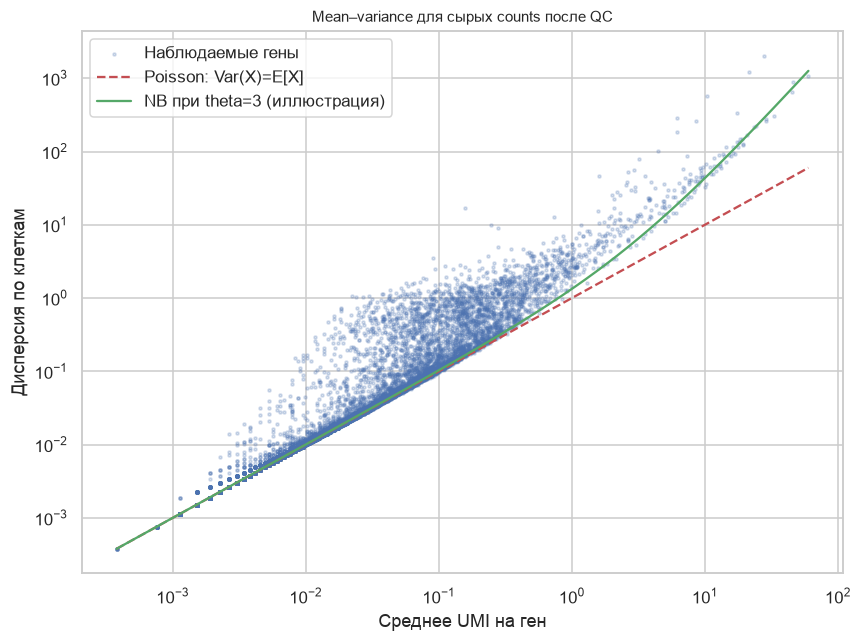

saved figures/04_mean_variance.png


Baseline PC1/PC2 variance ratio: [0.09977641 0.03281639]


In [5]:
hvg_v3_df = sc.pp.highly_variable_genes(adata_f, layer="counts", flavor="seurat_v3",
                                        n_top_genes=2000, inplace=False)
hvg_v3 = hvg_v3_df["highly_variable"].to_numpy()
adata_f.var["highly_variable"] = hvg_v3

means_raw, vars_raw = mean_var(adata_f.layers["counts"])
valid = (means_raw > 0) & (vars_raw > 0)
theta = 3
x = np.geomspace(means_raw[valid].min(), means_raw[valid].max(), 200)
plt.figure(figsize=(8, 6))
plt.scatter(means_raw[valid], vars_raw[valid], s=4, alpha=.22, label="Наблюдаемые гены", rasterized=True)
plt.plot(x, x, "r--", label="Poisson: Var(X)=E[X]")
plt.plot(x, x + x**2/theta, "g-", label="NB при theta=3 (иллюстрация)")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Среднее UMI на ген"); plt.ylabel("Дисперсия по клеткам")
plt.title("Mean–variance для сырых counts после QC"); plt.legend()
plt.tight_layout(); save_show("04_mean_variance.png")

adata_norm = adata_f.copy()
sc.pp.normalize_total(adata_norm, target_sum=1e4)
sc.pp.log1p(adata_norm)
baseline_pca = run_pca(adata_norm, hvg_v3)
print("Baseline PC1/PC2 variance ratio:", baseline_pca.uns["pca"]["variance_ratio"][:2])

### Задание 2. Сравнение методов HVG

Сравниваем `seurat_v3` на raw counts, `seurat` на нормализованных `log1p` values и experimental Pearson residuals на raw counts (`theta=100` — значение API по умолчанию). Во всех PCA используются одни и те же QC-filtered клетки, одна и та же normalized+log1p матрица и одинаковые настройки PCA; меняется только маска генов.

HVG intersections: {'seurat_v3__seurat': 1505, 'seurat_v3__pearson': 1402, 'seurat__pearson': 1291, 'all_three': 1145}


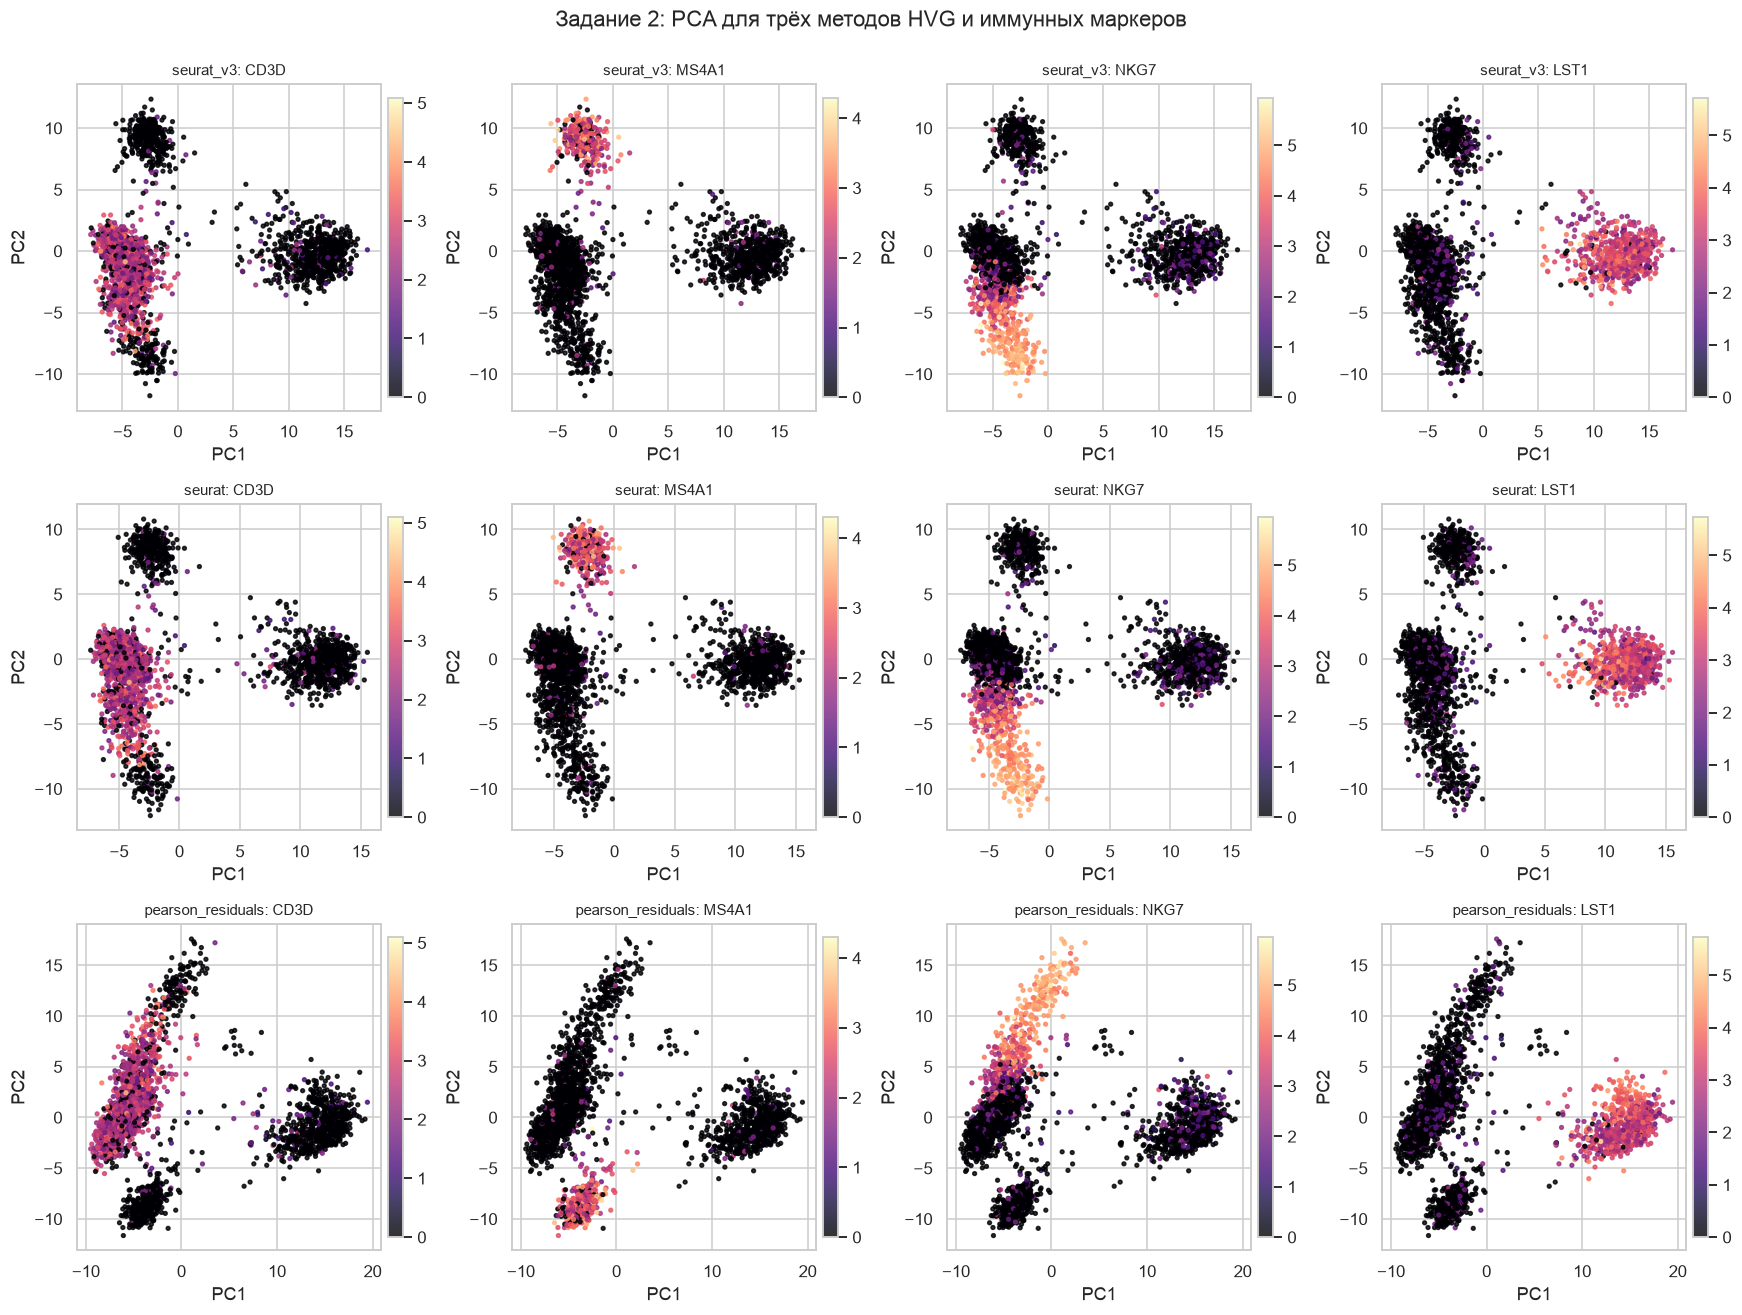

saved figures/05_hvg_methods_pca.png


In [6]:
hvg_seurat_df = sc.pp.highly_variable_genes(adata_norm, flavor="seurat", n_top_genes=2000, inplace=False)
hvg_seurat = hvg_seurat_df["highly_variable"].to_numpy()
hvg_pearson_df = sc.experimental.pp.highly_variable_genes(
    adata_f, layer="counts", flavor="pearson_residuals", n_top_genes=2000, inplace=False
)
hvg_pearson = hvg_pearson_df["highly_variable"].to_numpy()

hvg_sets = {
    "seurat_v3": set(adata_f.var_names[hvg_v3]),
    "seurat": set(adata_f.var_names[hvg_seurat]),
    "pearson_residuals": set(adata_f.var_names[hvg_pearson]),
}
hvg_intersections = {
    "seurat_v3__seurat": len(hvg_sets["seurat_v3"] & hvg_sets["seurat"]),
    "seurat_v3__pearson": len(hvg_sets["seurat_v3"] & hvg_sets["pearson_residuals"]),
    "seurat__pearson": len(hvg_sets["seurat"] & hvg_sets["pearson_residuals"]),
    "all_three": len(set.intersection(*hvg_sets.values())),
}
print("HVG intersections:", hvg_intersections)

masks = {"seurat_v3": hvg_v3, "seurat": hvg_seurat, "pearson_residuals": hvg_pearson}
embeddings_hvg, variance_hvg = {}, {}
for name, mask in masks.items():
    p = run_pca(adata_norm, mask)
    embeddings_hvg[name] = p.obsm["X_pca"].copy()
    variance_hvg[name] = p.uns["pca"]["variance_ratio"][:10].copy()

markers = ["CD3D", "MS4A1", "NKG7", "LST1"]
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for i, (method, emb) in enumerate(embeddings_hvg.items()):
    for j, gene in enumerate(markers):
        scatter_embedding(axes[i, j], emb, gene_values(adata_norm, gene), f"{method}: {gene}", cmap="magma")
fig.suptitle("Задание 2: PCA для трёх методов HVG и иммунных маркеров", y=.995)
plt.tight_layout(); save_show("05_hvg_methods_pca.png")

### Задание 3. PCA без отбора HVG

Здесь нормализация, `log1p`, клетки и параметры PCA одинаковы. Единственное различие использование всех генов после QC либо 2000 baseline HVG. Сравниваем структуру по тем же четырём маркерам и долю объяснённой дисперсии.

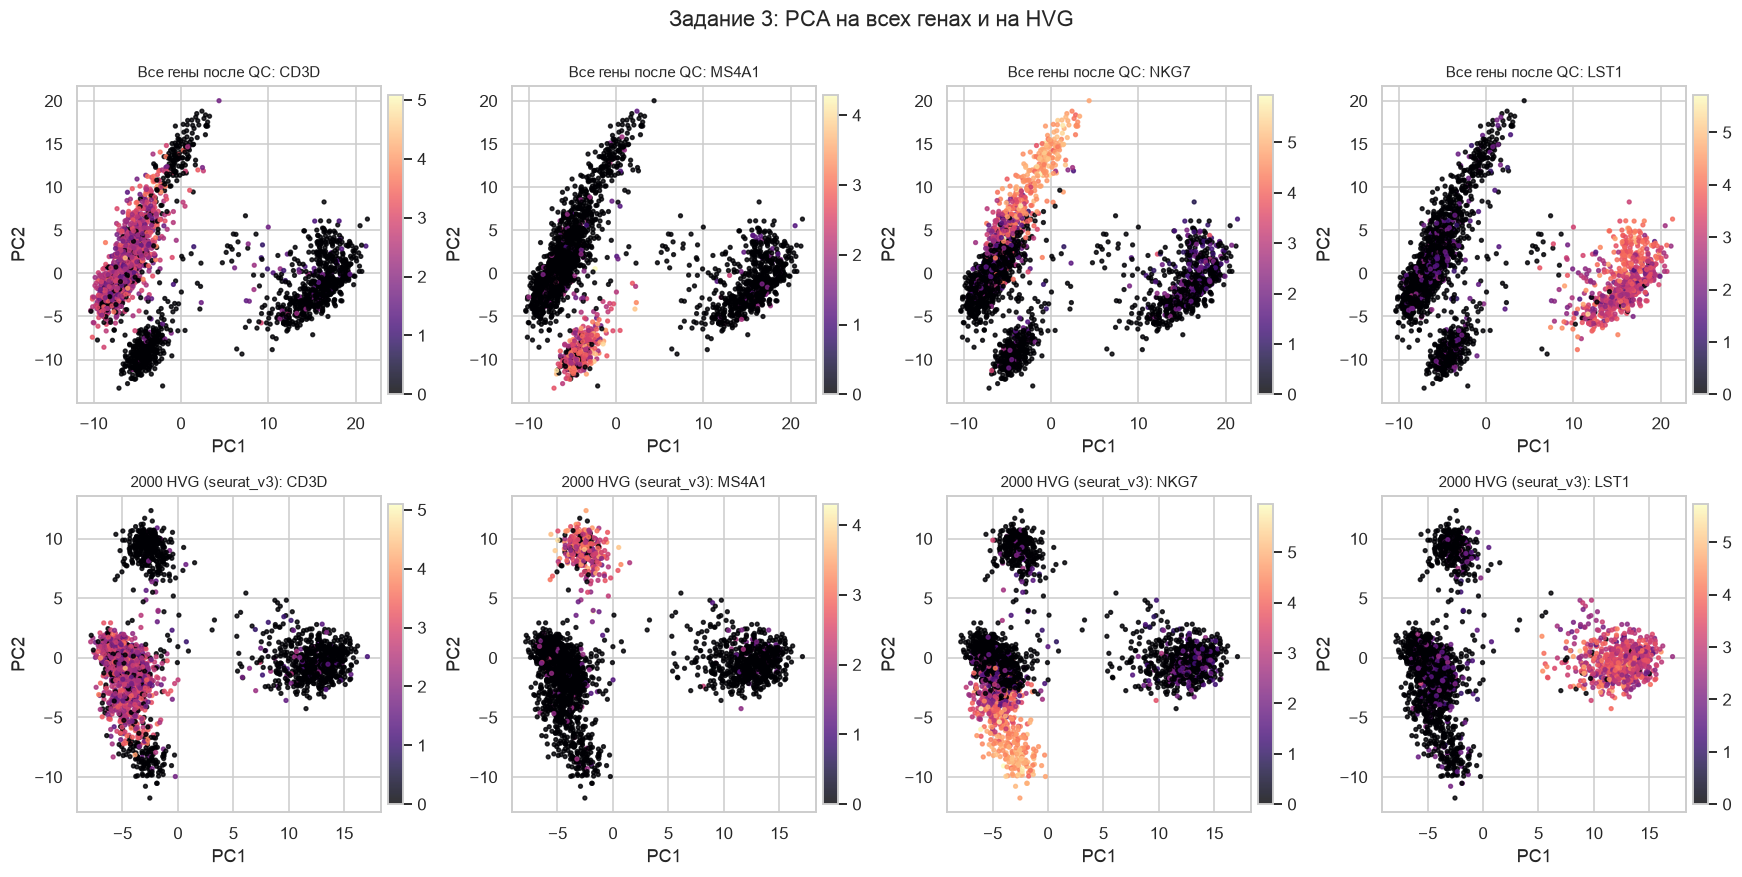

saved figures/06_all_genes_vs_hvg_pca.png


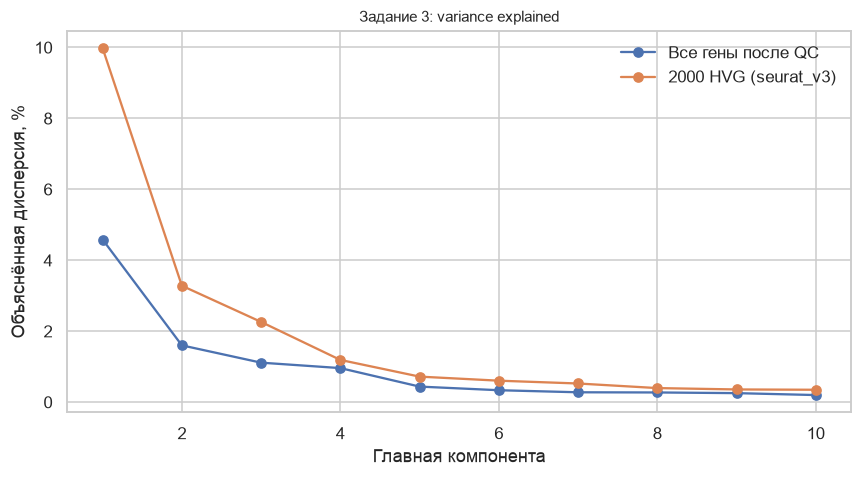

saved figures/07_all_genes_vs_hvg_variance.png


In [7]:
pca_all = run_pca(adata_norm, None)
pca_hvg = baseline_pca
pca_gene_sets = {"Все гены после QC": pca_all, "2000 HVG (seurat_v3)": pca_hvg}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, (label, p) in enumerate(pca_gene_sets.items()):
    for j, gene in enumerate(markers):
        scatter_embedding(axes[i, j], p.obsm["X_pca"], gene_values(adata_norm, gene), f"{label}: {gene}", cmap="magma")
fig.suptitle("Задание 3: PCA на всех генах и на HVG", y=.995)
plt.tight_layout(); save_show("06_all_genes_vs_hvg_pca.png")

variance_gene_sets = {
    label: p.uns["pca"]["variance_ratio"][:10].tolist() for label, p in pca_gene_sets.items()
}
fig, ax = plt.subplots(figsize=(8, 4.5))
for label, values in variance_gene_sets.items():
    ax.plot(np.arange(1, 11), np.array(values) * 100, marker="o", label=label)
ax.set(xlabel="Главная компонента", ylabel="Объяснённая дисперсия, %",
       title="Задание 3: variance explained")
ax.legend(frameon=False); plt.tight_layout(); save_show("07_all_genes_vs_hvg_variance.png")

### Задание 4. HVG и уровень экспрессии

Для HVG и non-HVG выбираем TOP 50 по среднему сырому UMI count на клетку. 

mean_raw_umi                                                        \
               count    mean     std    min    25%     50%     75%     max   
set                                                                          
HVG             50.0   7.149  12.292  1.217  1.982   2.627   4.812  60.037   
non-HVG         50.0  14.332   5.718  8.438  9.684  12.928  17.394  33.017   

        variance_raw_umi                                                     \
                   count     mean      std     min     25%     50%      75%   
set                                                                           
HVG                 50.0  173.144  383.372   5.533  12.164  29.460   73.720   
non-HVG             50.0   94.367   65.988  30.580  49.252  67.716  116.073   

                   
              max  
set                
HVG      2041.886  
non-HVG   307.453

set,HVG,non-HVG
category,,
HLA,4,0
mitochondrial,1,1
other,45,4
ribosomal,0,45


,set,rank,gene,mean_raw_umi,variance_raw_umi,category
0,HVG,1,MALAT1,60.036732,1066.570312,other
1,HVG,2,TMSB4X,46.140289,883.349854,other
2,HVG,3,B2M,45.289223,659.148682,other
3,HVG,4,FTL,27.999430,2041.886475,other
4,HVG,5,FTH1,21.535463,1224.520508,other
5,HVG,6,ACTB,17.458569,334.396576,other
6,HVG,7,LYZ,10.408192,575.139343,other
7,HVG,8,CD74,8.579643,261.793152,other
8,HVG,9,S100A4,7.343126,86.244446,other
9,HVG,10,MT-CO2,6.888643,56.957253,mitochondrial


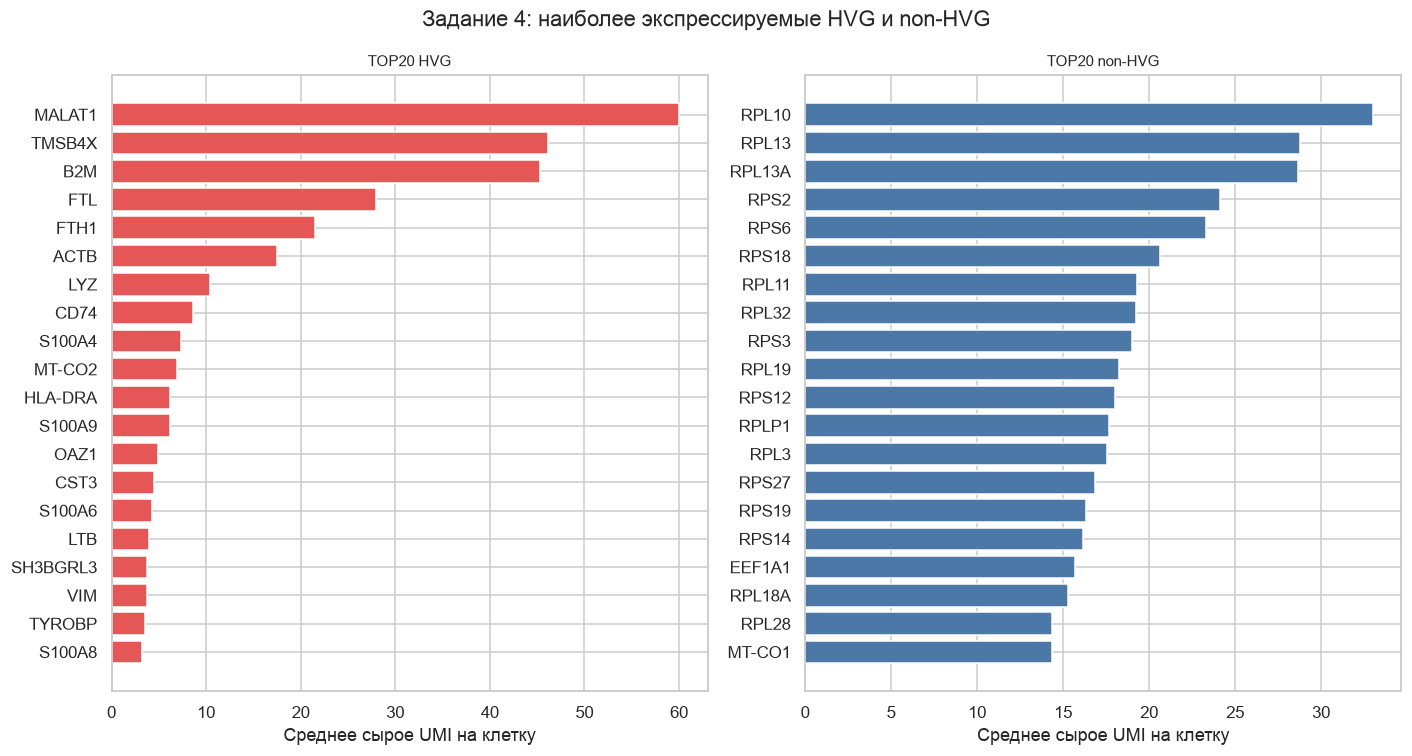

saved figures/08_top_expressed_hvg_nonhvg.png


In [8]:
def gene_category(g):
    if g.startswith(("RPL", "RPS")): return "ribosomal"
    if g.startswith("MT-"): return "mitochondrial"
    if g.startswith(("HBA", "HBB")): return "hemoglobin"
    if g.startswith(("IGH", "IGK", "IGL")): return "immunoglobulin"
    if g.startswith("HLA-"): return "HLA"
    if g.startswith("HIST"): return "histone"
    return "other"

rows = []
for label, mask in [("HVG", hvg_v3), ("non-HVG", ~hvg_v3)]:
    idx = np.flatnonzero(mask)
    order = idx[np.argsort(means_raw[idx])[::-1][:50]]
    for rank, k in enumerate(order, 1):
        rows.append({"set": label, "rank": rank, "gene": adata_f.var_names[k],
                     "mean_raw_umi": means_raw[k], "variance_raw_umi": vars_raw[k],
                     "category": gene_category(adata_f.var_names[k])})
top50 = pd.DataFrame(rows)
top50.to_csv(TABLES / "top50_hvg_nonhvg.tsv", sep="\t", index=False)
display(top50.groupby("set")[["mean_raw_umi", "variance_raw_umi"]].describe().round(3))
display(pd.crosstab(top50["category"], top50["set"]))
display(top50.groupby("set").head(15))

fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharex=False)
for ax, label, color in zip(axes, ["HVG", "non-HVG"], ["#e45756", "#4c78a8"]):
    d = top50[top50["set"] == label].head(20).sort_values("mean_raw_umi")
    ax.barh(d["gene"], d["mean_raw_umi"], color=color)
    ax.set(xlabel="Среднее сырое UMI на клетку", title=f"TOP20 {label}")
fig.suptitle("Задание 4: наиболее экспрессируемые HVG и non-HVG")
plt.tight_layout(); save_show("08_top_expressed_hvg_nonhvg.png")

### Задание 5. Влияние QC-фильтрации и HVG на PCA

Четыре сценария строятся независимо. Метрики для вариантов без фильтрации вычислены на исходной матрице, а для вариантов с фильтрацией на соответствующем объекте после QC. Вычисление QC-метрик не означает, что клетки были отфильтрованы.

A: без QC, все гены (2700, 32738)


B: без QC, HVG (2700, 32738)


C: с QC, все гены (2638, 13714)


D: с QC, HVG (2638, 13714)


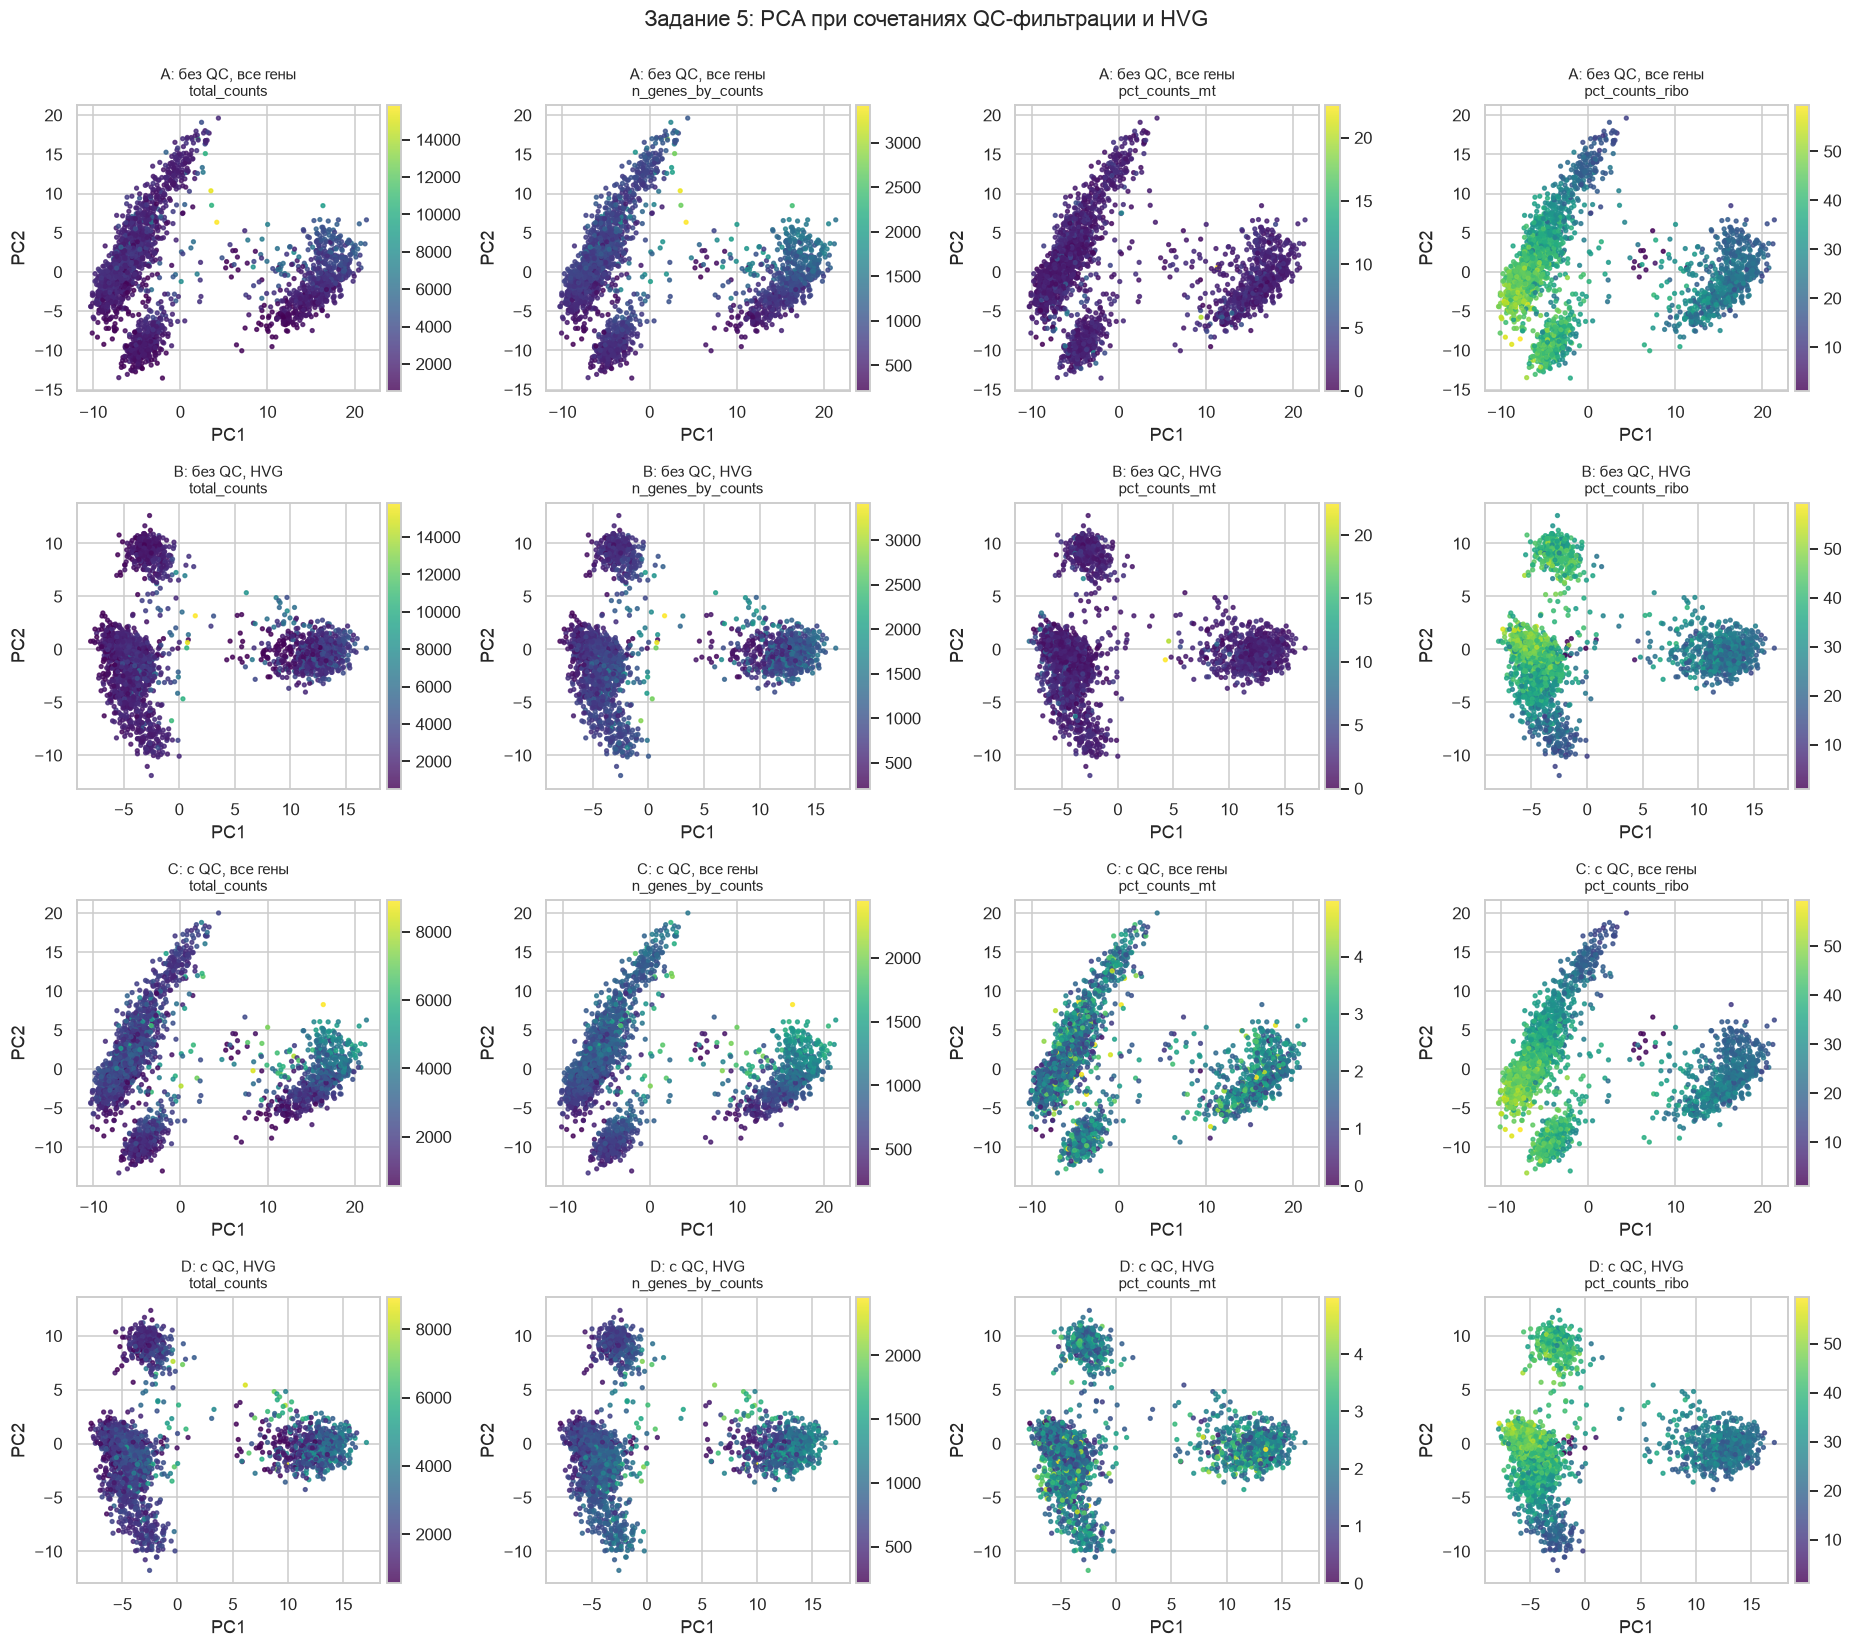

saved figures/09_qc_hvg_scenarios_pca.png


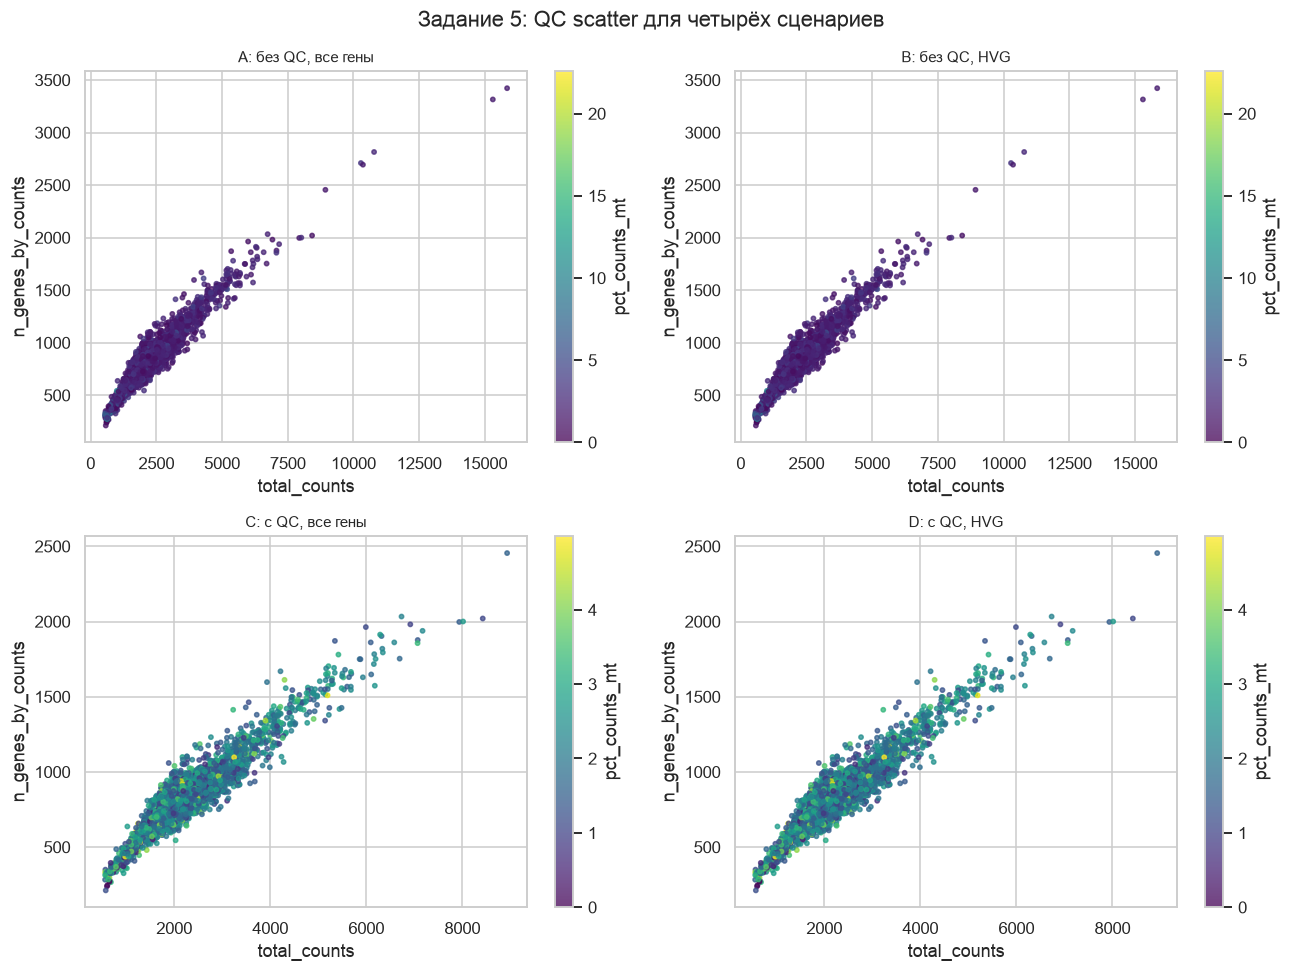

saved figures/10_qc_hvg_scenarios_scatter.png


,variance_pc1,variance_pc2,corr_PC1_total_counts,corr_PC1_n_genes_by_counts,corr_PC1_pct_counts_mt,corr_PC1_pct_counts_ribo,corr_PC2_total_counts,corr_PC2_n_genes_by_counts,corr_PC2_pct_counts_mt,corr_PC2_pct_counts_ribo
"A: без QC, все гены",0.045,0.016,0.282,0.347,0.108,-0.755,0.289,0.457,-0.063,-0.387
"B: без QC, HVG",0.099,0.033,0.302,0.345,0.082,-0.661,-0.083,-0.201,-0.006,0.329
"C: с QC, все гены",0.046,0.016,0.308,0.372,0.158,-0.759,0.224,0.405,-0.022,-0.413
"D: с QC, HVG",0.100,0.033,0.330,0.366,0.145,-0.671,-0.078,-0.202,-0.013,0.339


In [9]:
def prepare_scenario(source_counts, use_hvg):
    obj_counts = source_counts.copy()
    if use_hvg:
        h = sc.pp.highly_variable_genes(obj_counts, flavor="seurat_v3", n_top_genes=2000, inplace=False)["highly_variable"].to_numpy()
    else:
        h = None
    obj = obj_counts.copy()
    sc.pp.normalize_total(obj, target_sum=1e4)
    sc.pp.log1p(obj)
    return run_pca(obj, h), h

scenario_sources = {
    "A: без QC, все гены": (adata_raw, False),
    "B: без QC, HVG": (adata_raw, True),
    "C: с QC, все гены": (adata_f, False),
    "D: с QC, HVG": (adata_f, True),
}
scenarios = {}
for label, (src, use_hvg) in scenario_sources.items():
    scenarios[label] = prepare_scenario(src, use_hvg)[0]
    print(label, scenarios[label].shape)

scenario_colors = ["total_counts", "n_genes_by_counts", "pct_counts_mt", "pct_counts_ribo"]
fig, axes = plt.subplots(4, 4, figsize=(17, 15))
for i, (label, p) in enumerate(scenarios.items()):
    for j, m in enumerate(scenario_colors):
        scatter_embedding(axes[i, j], p.obsm["X_pca"], p.obs[m].to_numpy(), f"{label}\n{m}")
fig.suptitle("Задание 5: PCA при сочетаниях QC-фильтрации и HVG", y=.998)
plt.tight_layout(); save_show("09_qc_hvg_scenarios_pca.png")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (label, p) in zip(axes.ravel(), scenarios.items()):
    pts = ax.scatter(p.obs.total_counts, p.obs.n_genes_by_counts, c=p.obs.pct_counts_mt,
                     s=8, alpha=.75, cmap="viridis", rasterized=True)
    ax.set(xlabel="total_counts", ylabel="n_genes_by_counts", title=label)
    plt.colorbar(pts, ax=ax, label="pct_counts_mt")
fig.suptitle("Задание 5: QC scatter для четырёх сценариев")
plt.tight_layout(); save_show("10_qc_hvg_scenarios_scatter.png")

scenario_stats = {}
for label, p in scenarios.items():
    rec = {"variance_pc1": float(p.uns["pca"]["variance_ratio"][0]),
           "variance_pc2": float(p.uns["pca"]["variance_ratio"][1])}
    for pc in [0, 1]:
        for m in scenario_colors:
            rec[f"corr_PC{pc+1}_{m}"] = float(np.corrcoef(p.obsm["X_pca"][:, pc], p.obs[m])[0, 1])
    scenario_stats[label] = rec
pd.DataFrame(scenario_stats).T.round(3)

### Задание 6. PCA loadings

Извлекаем нагрузки именно из baseline PCA (QC-filtered клетки, 2000 `seurat_v3` HVG, normalized+log1p). Знак оси PCA произволен, важны противоположные концы компоненты и величины нагрузок.

,PC,side,rank,gene,loading
0,PC1,positive,1,LYZ,0.220199
1,PC1,positive,2,CST3,0.212370
2,PC1,positive,3,S100A9,0.210871
3,PC1,positive,4,TYROBP,0.199072
4,PC1,positive,5,S100A8,0.170560
5,PC1,positive,6,LGALS1,0.168186
6,PC1,positive,7,AIF1,0.166196
7,PC1,positive,8,LST1,0.165629
8,PC1,positive,9,FCER1G,0.156248
9,PC1,positive,10,FCN1,0.150878


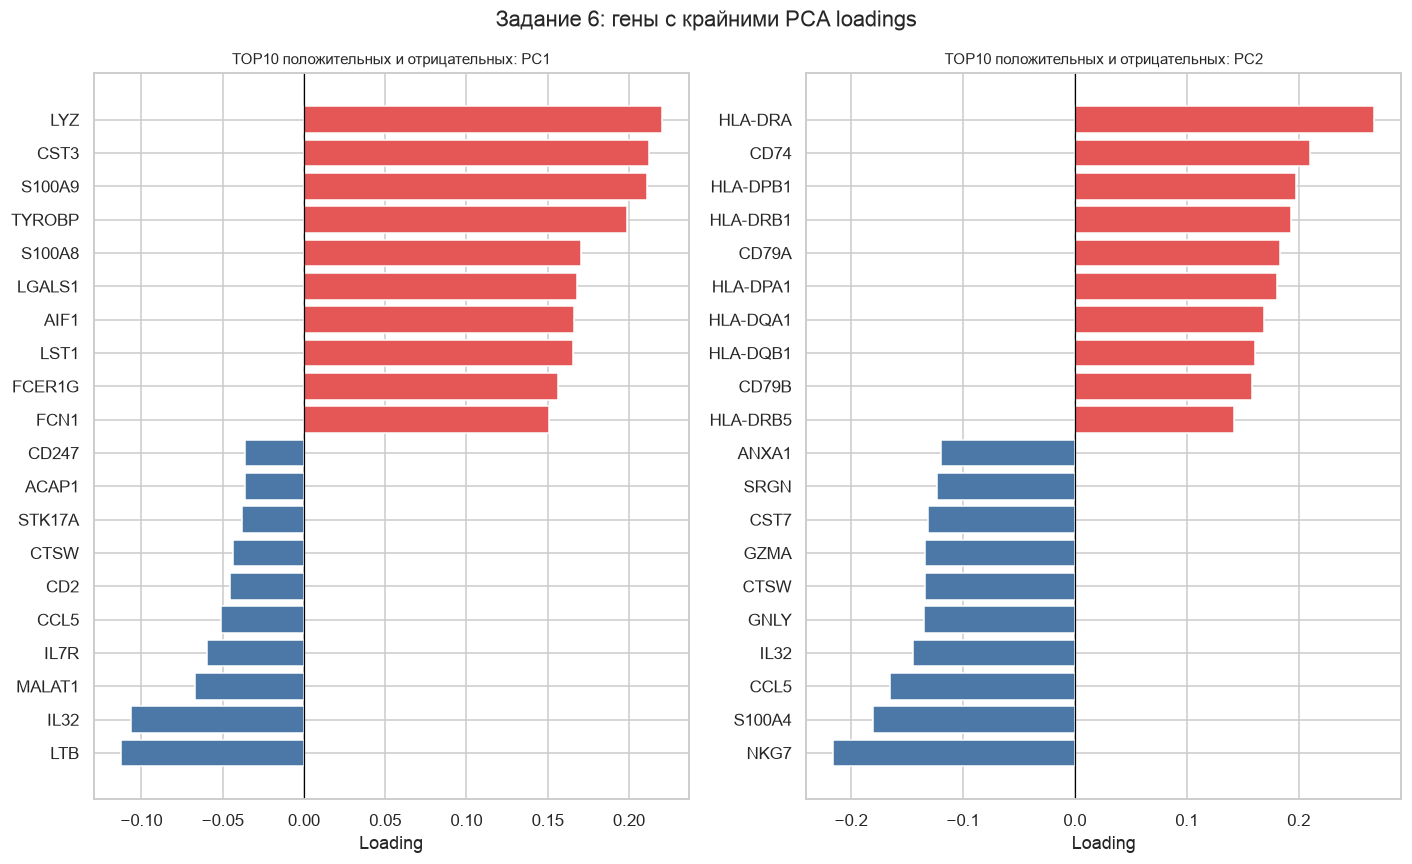

saved figures/11_pca_loadings.png


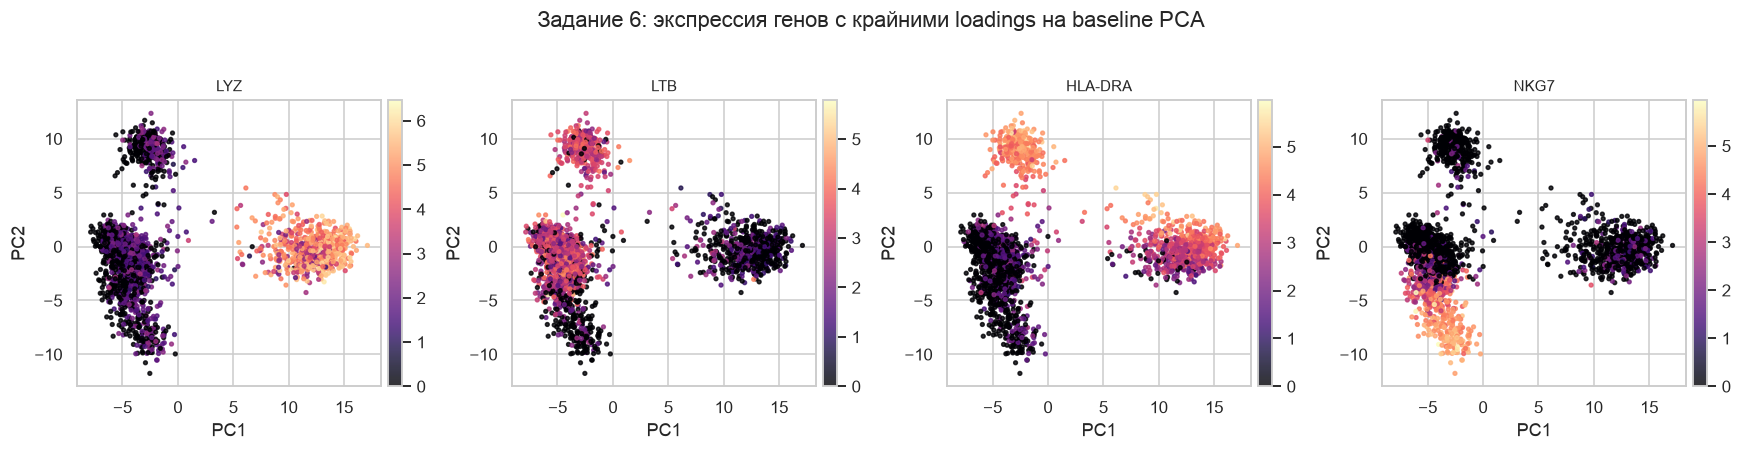

saved figures/12_loading_genes_expression.png


In [10]:
pc_load = baseline_pca.varm["PCs"]
hvg_idx = np.flatnonzero(hvg_v3)
loading_rows = []
for pc in [0, 1]:
    vals = pc_load[hvg_idx, pc]
    pos = hvg_idx[np.argsort(vals)[-10:][::-1]]
    neg = hvg_idx[np.argsort(vals)[:10]]
    for side, idxs in [("positive", pos), ("negative", neg)]:
        for rank, k in enumerate(idxs, 1):
            loading_rows.append({"PC": f"PC{pc+1}", "side": side, "rank": rank,
                                 "gene": baseline_pca.var_names[k], "loading": pc_load[k, pc]})
loadings = pd.DataFrame(loading_rows)
loadings.to_csv(TABLES / "pca_loadings_top10.tsv", sep="\t", index=False)
display(loadings)

fig, axes = plt.subplots(1, 2, figsize=(13, 8))
for ax, pc in zip(axes, ["PC1", "PC2"]):
    d = loadings[loadings.PC == pc].sort_values("loading")
    ax.barh(d.gene, d.loading, color=np.where(d.loading > 0, "#e45756", "#4c78a8"))
    ax.axvline(0, color="black", lw=.8)
    ax.set(xlabel="Loading", title=f"TOP10 положительных и отрицательных: {pc}")
fig.suptitle("Задание 6: гены с крайними PCA loadings")
plt.tight_layout(); save_show("11_pca_loadings.png")

selected_loading_genes = []
for pc in ["PC1", "PC2"]:
    for side in ["positive", "negative"]:
        selected_loading_genes.append(loadings.query("PC == @pc and side == @side").iloc[0].gene)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, gene in zip(axes, selected_loading_genes):
    scatter_embedding(ax, baseline_pca.obsm["X_pca"], gene_values(adata_norm, gene), gene, cmap="magma")
fig.suptitle("Задание 6: экспрессия генов с крайними loadings на baseline PCA", y=1.02)
plt.tight_layout(); save_show("12_loading_genes_expression.png")

### Задание 7. Preprocessing и PCA

Во всех четырёх вариантах используются одни и те же QC-filtered клетки и одни и те же 2000 baseline HVG. Меняется только preprocessing: baseline `normalize_total+log1p`; без `log1p`; raw counts без нормализации и логарифма; baseline плюс `scale`. Таким образом, мы не применяем `log1p` или нормализацию повторно.

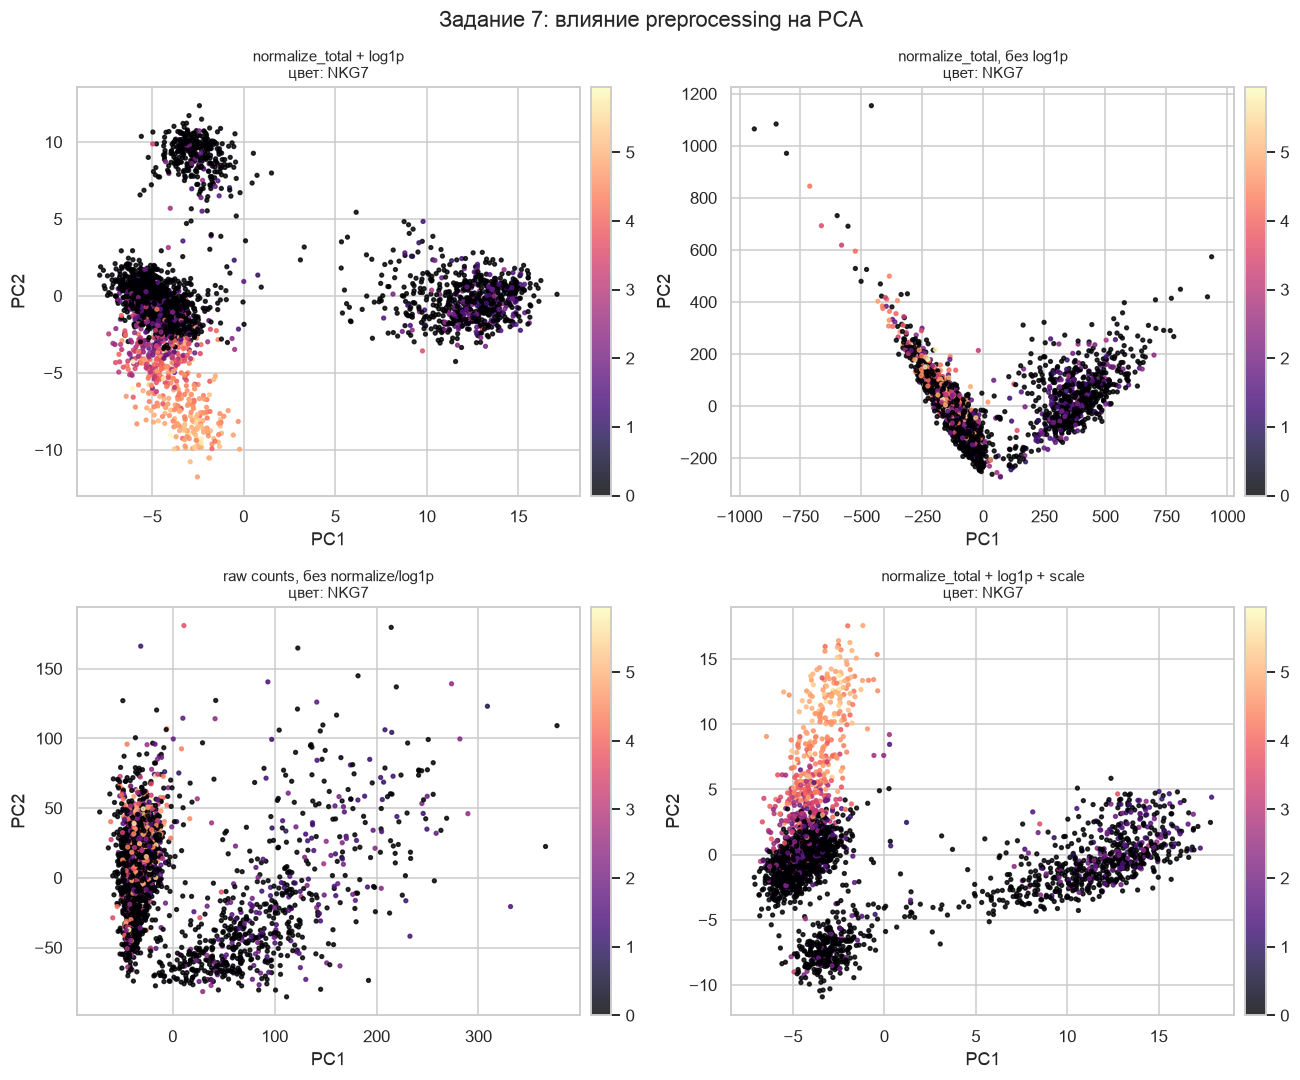

saved figures/13_preprocessing_pca.png


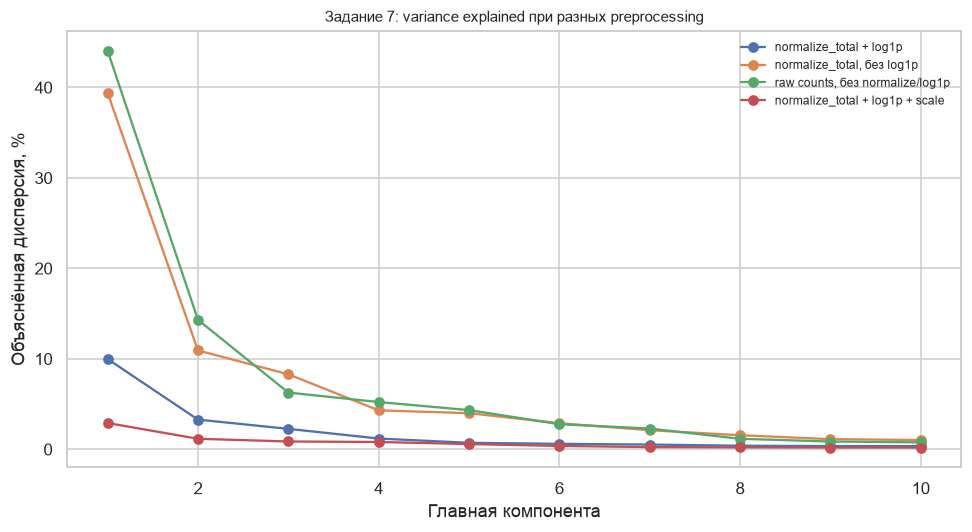

saved figures/14_preprocessing_variance.png


,variance_pc1,variance_pc2,variance_first10,corr_PC1_total_counts,corr_PC2_total_counts
normalize_total + log1p,0.100,0.033,0.197,0.330,-0.078
"normalize_total, без log1p",0.394,0.109,0.756,0.228,-0.229
"raw counts, без normalize/log1p",0.441,0.143,0.821,0.575,0.562
normalize_total + log1p + scale,0.029,0.012,0.076,0.379,0.205


In [11]:
# Library-size normalization is calculated from all genes and only then are the
# same baseline HVGs selected for PCA. Subsetting before normalize_total would
# silently change each cell's size factor.
full_counts = adata_f.copy()
full_counts.X = adata_f.layers["counts"].copy()
prep_objects = {}

base_full = full_counts.copy(); sc.pp.normalize_total(base_full, target_sum=1e4); sc.pp.log1p(base_full)
base = base_full[:, hvg_v3].copy()
prep_objects["normalize_total + log1p"] = run_pca(base)

norm_only_full = full_counts.copy(); sc.pp.normalize_total(norm_only_full, target_sum=1e4)
norm_only = norm_only_full[:, hvg_v3].copy()
prep_objects["normalize_total, без log1p"] = run_pca(norm_only)

raw_hvg = full_counts[:, hvg_v3].copy()
prep_objects["raw counts, без normalize/log1p"] = run_pca(raw_hvg)

scaled = base.copy(); sc.pp.scale(scaled, max_value=10)
prep_objects["normalize_total + log1p + scale"] = run_pca(scaled)

marker_color = gene_values(adata_norm, "NKG7")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (label, p) in zip(axes.ravel(), prep_objects.items()):
    scatter_embedding(ax, p.obsm["X_pca"], marker_color, label + "\nцвет: NKG7", cmap="magma")
fig.suptitle("Задание 7: влияние preprocessing на PCA")
plt.tight_layout(); save_show("13_preprocessing_pca.png")

preprocessing_stats = {}
for label, p in prep_objects.items():
    vr = p.uns["pca"]["variance_ratio"][:10]
    preprocessing_stats[label] = {
        "variance_pc1": float(vr[0]), "variance_pc2": float(vr[1]),
        "variance_first10": float(vr.sum()),
        "corr_PC1_total_counts": float(np.corrcoef(p.obsm["X_pca"][:, 0], p.obs.total_counts)[0, 1]),
        "corr_PC2_total_counts": float(np.corrcoef(p.obsm["X_pca"][:, 1], p.obs.total_counts)[0, 1]),
    }

fig, ax = plt.subplots(figsize=(9, 5))
for label, p in prep_objects.items():
    ax.plot(np.arange(1, 11), p.uns["pca"]["variance_ratio"][:10] * 100, marker="o", label=label)
ax.set(xlabel="Главная компонента", ylabel="Объяснённая дисперсия, %",
       title="Задание 7: variance explained при разных preprocessing")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); save_show("14_preprocessing_variance.png")
pd.DataFrame(preprocessing_stats).T.round(3)